In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
model = joblib.load("../models/phishing_detector.pkl")

X_test = joblib.load("../models/X_test.pkl")
y_test = joblib.load("../models/y_test.pkl")

In [3]:
y_pred = model.predict(X_test)

In [4]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       902
           1       0.99      0.93      0.96       131

    accuracy                           0.99      1033
   macro avg       0.99      0.97      0.98      1033
weighted avg       0.99      0.99      0.99      1033



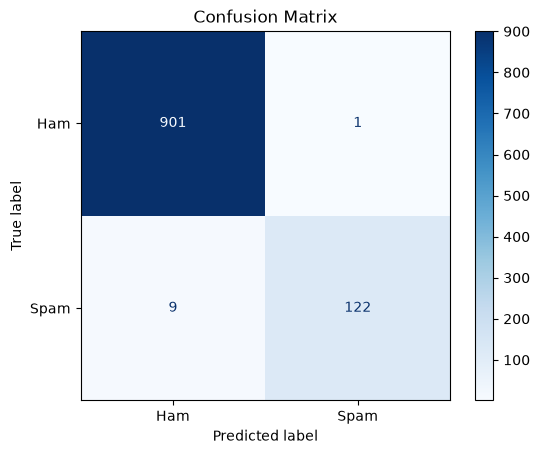

In [5]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [6]:
results = pd.read_csv("../reports/model_comparison.csv")

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Neural Network,0.990319,0.991870,0.931298,0.960630
1,Random Forest,0.988383,0.991736,0.916031,0.952381
2,Logistic Regression,0.979671,0.950820,0.885496,0.916996
3,Support Vector Machine,0.977735,0.921875,0.900763,0.911197
4,Decision Tree,0.968054,0.840278,0.923664,0.880000
5,Naive Bayes,0.949661,0.751592,0.900763,0.819444


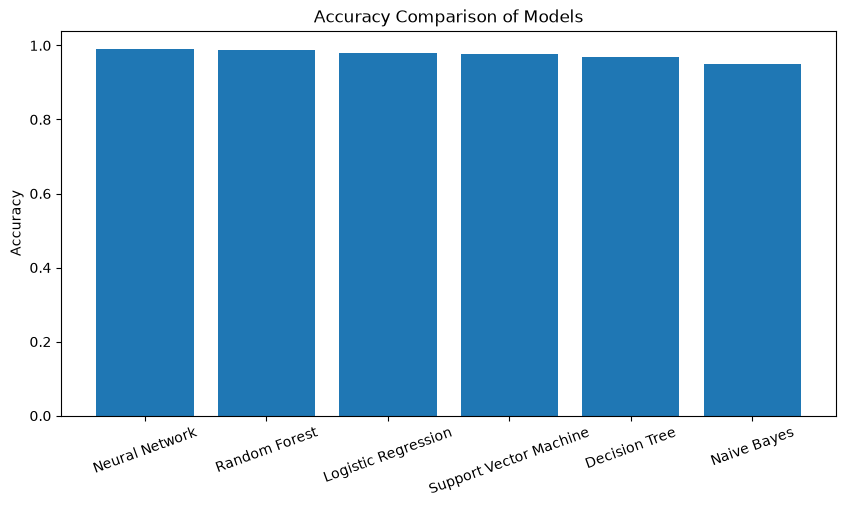

In [7]:
plt.figure(figsize=(10,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.xticks(rotation=20)

plt.ylabel("Accuracy")

plt.title("Accuracy Comparison of Models")

plt.show()

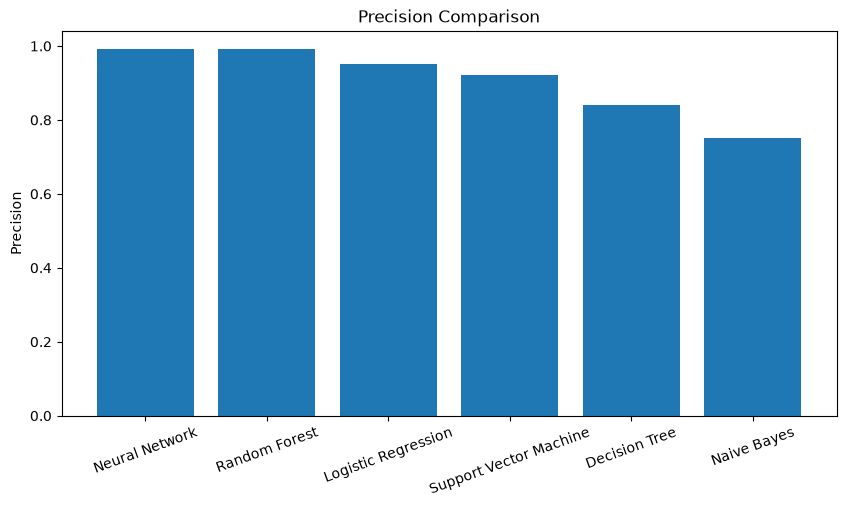

In [8]:
plt.figure(figsize=(10,5))

plt.bar(
    results["Model"],
    results["Precision"]
)

plt.xticks(rotation=20)

plt.ylabel("Precision")

plt.title("Precision Comparison")

plt.show()

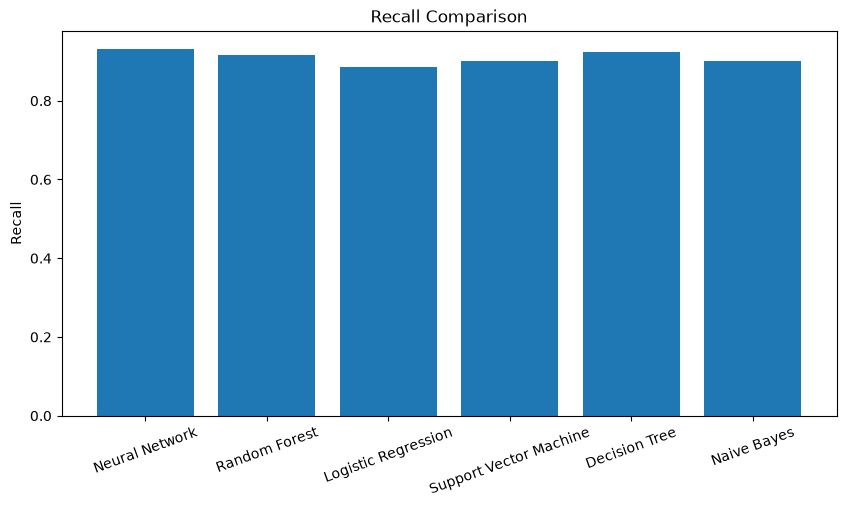

In [9]:
plt.figure(figsize=(10,5))

plt.bar(
    results["Model"],
    results["Recall"]
)

plt.xticks(rotation=20)

plt.ylabel("Recall")

plt.title("Recall Comparison")

plt.show()

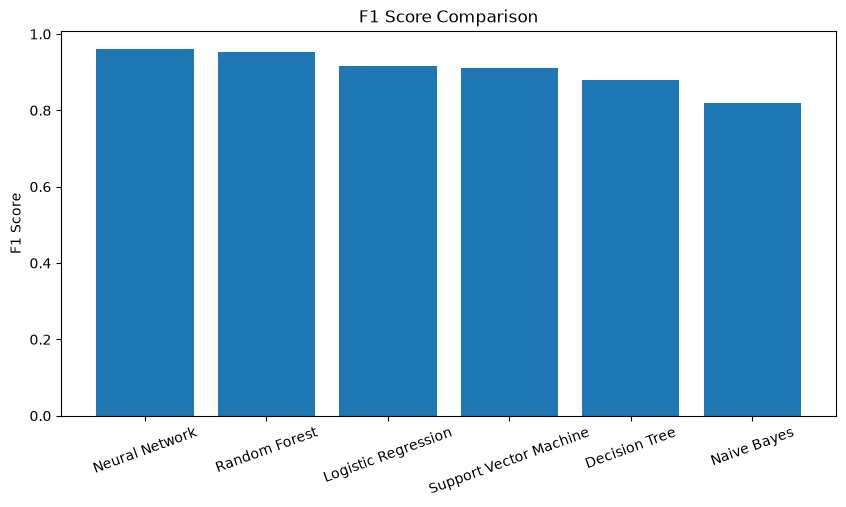

In [10]:
plt.figure(figsize=(10,5))

plt.bar(
    results["Model"],
    results["F1 Score"]
)

plt.xticks(rotation=20)

plt.ylabel("F1 Score")

plt.title("F1 Score Comparison")

plt.show()

In [11]:
print("=" * 60)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 60)

print(results.round(4))

best = results.iloc[0]

print("\nBest Performing Model")
print("----------------------")
print(f"Model     : {best['Model']}")
print(f"Accuracy  : {best['Accuracy']:.4f}")
print(f"Precision : {best['Precision']:.4f}")
print(f"Recall    : {best['Recall']:.4f}")
print(f"F1 Score  : {best['F1 Score']:.4f}")

MODEL PERFORMANCE SUMMARY
                    Model  Accuracy  Precision  Recall  F1 Score
0          Neural Network    0.9903     0.9919  0.9313    0.9606
1           Random Forest    0.9884     0.9917  0.9160    0.9524
2     Logistic Regression    0.9797     0.9508  0.8855    0.9170
3  Support Vector Machine    0.9777     0.9219  0.9008    0.9112
4           Decision Tree    0.9681     0.8403  0.9237    0.8800
5             Naive Bayes    0.9497     0.7516  0.9008    0.8194

Best Performing Model
----------------------
Model     : Neural Network
Accuracy  : 0.9903
Precision : 0.9919
Recall    : 0.9313
F1 Score  : 0.9606


In [ ]:
## Conclusion

### Observations

##- Six machine learning algorithms were evaluated.
##- The Neural Network achieved the highest accuracy (**99.03%**) and F1 Score (**96.06%**).
##- Random Forest also performed strongly and is a good alternative due to its interpretability.
##- The trained Neural Network model will be used in the prediction and deployment stages.

In [12]:
with open("../reports/model_evaluation.txt", "w") as f:
    f.write(classification_report(y_test, y_pred))

print("Evaluation report saved successfully.")

Evaluation report saved successfully.
